In [1]:
# importing the required libraries

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Loading the data 

fc_part1 = pd.read_excel(
    "/Users/arjun/Library/CloudStorage/OneDrive-TechnischeHochschuleRosenheim/FC_Part1.xlsx",
    decimal=",",
)
fc_part2 = pd.read_excel(
    "/Users/arjun/Library/CloudStorage/OneDrive-TechnischeHochschuleRosenheim/FC_Part2.xlsx",
    decimal=",",
)
fc_init = pd.concat([fc_part1, fc_part2])
fc_init.index = pd.to_timedelta(fc_init["Time (h)"], unit="h")
df = fc_init.sort_index()
df = df[~df.index.duplicated(keep="first")]

In [3]:
# Converting the dataset to hourly format

df_hourly = df.resample("1h").mean().dropna()
df_hourly["hours_elapsed"] = df_hourly.index.total_seconds() / 3600.0
fc = df_hourly.reset_index(drop=True)

In [4]:
# Extracting the optimal voltage at 0 hour and calculating the voltage loss

polarisation_df = pd.read_excel(
    "/Users/arjun/Desktop/Project Thesis/FC1_FC2_Excel 2/FC2_With_Ripples_Excel/FC2_Pola_T000.xlsx"
)
pola_t00 = polarisation_df.sort_values(by="I (A)")
fc["U0"] = np.interp(fc["I (A)"], pola_t00["I (A)"], pola_t00["Ustack (V)"])
fc["voltage_loss_pct"] = (fc["U0"] - fc["Utot (V)"]) / fc["U0"] * 100
fc["target"] = fc["voltage_loss_pct"].rolling(window=20, min_periods=1).mean()

In [5]:
# Creating required features for the model

FEATURES = ["I (A)","TinWAT (ｰC)","ToutH2 (ｰC)","ToutAIR (ｰC)"]
LAGS = [1, 6, 24]
ROLL_WINDOWS = [6, 24]
DIFF_LAGS = [1, 6, 24]
TEST_FRACTION = 0.2
REANCHOR_INTERVAL = 24  # hours between assumed fresh measurements

data = fc[["hours_elapsed"] + FEATURES + ["target"]].copy()

for col in FEATURES:
    for lag in LAGS:
        data[f"{col}_lag{lag}"] = data[col].shift(lag)
    for win in ROLL_WINDOWS:
        data[f"{col}_rollmean{win}"] = data[col].rolling(win).mean()

data["target_diff"] = data["target"].diff()
for lag in DIFF_LAGS:
    data[f"target_diff_lag{lag}"] = data["target_diff"].shift(lag)

data = data.dropna().reset_index(drop=True)

# hours_elapsed excluded: it's just a time index, not a physical driver,
# and would let the model "cheat" by learning the train/test boundary.
feature_cols = [c for c in data.columns if c not in ("target", "target_diff", "hours_elapsed")]


In [6]:
# Splitting the data and defining the model

split_idx = int(len(data) * (1 - TEST_FRACTION))
train_df = data.iloc[:split_idx].reset_index(drop=True)
test_df = data.iloc[split_idx:].reset_index(drop=True)

model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
)
model.fit(train_df[feature_cols], train_df["target_diff"], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predicting on the unseen data

n = len(test_df)
actual = test_df["target"].values
reconstructed = np.zeros(n)

diff_history = list(train_df["target_diff"].values)
current_level = train_df["target"].iloc[-1]
exog_buffers = {col: list(train_df[col].values) for col in FEATURES}

for i in range(n):
    if i % REANCHOR_INTERVAL == 0:
        current_level = train_df["target"].iloc[-1] if i == 0 else actual[i - 1]
        diff_history = list(train_df["target_diff"].values) + list(test_df["target_diff"].values[:i])
        exog_buffers = {
            col: list(train_df[col].values) + list(test_df[col].values[:i]) for col in FEATURES
        }

    row = {}
    for col in FEATURES:
        exog_buffers[col].append(exog_buffers[col][-1])
        buf = exog_buffers[col]
        row[col] = buf[-1]
        for lag in LAGS:
            row[f"{col}_lag{lag}"] = buf[-1 - lag] if len(buf) > lag else buf[0]
        for win in ROLL_WINDOWS:
            row[f"{col}_rollmean{win}"] = float(np.mean(buf[-win:]))
    for lag in DIFF_LAGS:
        row[f"target_diff_lag{lag}"] = diff_history[-lag] if len(diff_history) >= lag else 0.0

    pred_diff = model.predict(pd.DataFrame([row])[feature_cols])[0]
    current_level += pred_diff
    reconstructed[i] = current_level
    diff_history.append(pred_diff)

MAE:  0.17649068149427471
RMSE: 0.27401716036561213
R2:   0.8891955200112619

Top feature importances:
target_diff_lag1          0.270485
I (A)                     0.114427
I (A)_rollmean6           0.075355
I (A)_rollmean24          0.070367
TinWAT (ｰC)               0.045675
ToutH2 (ｰC)               0.037728
target_diff_lag6          0.034016
TinWAT (ｰC)_rollmean24    0.032556
ToutAIR (ｰC)_lag1         0.031627
I (A)_lag6                0.031271
dtype: float32


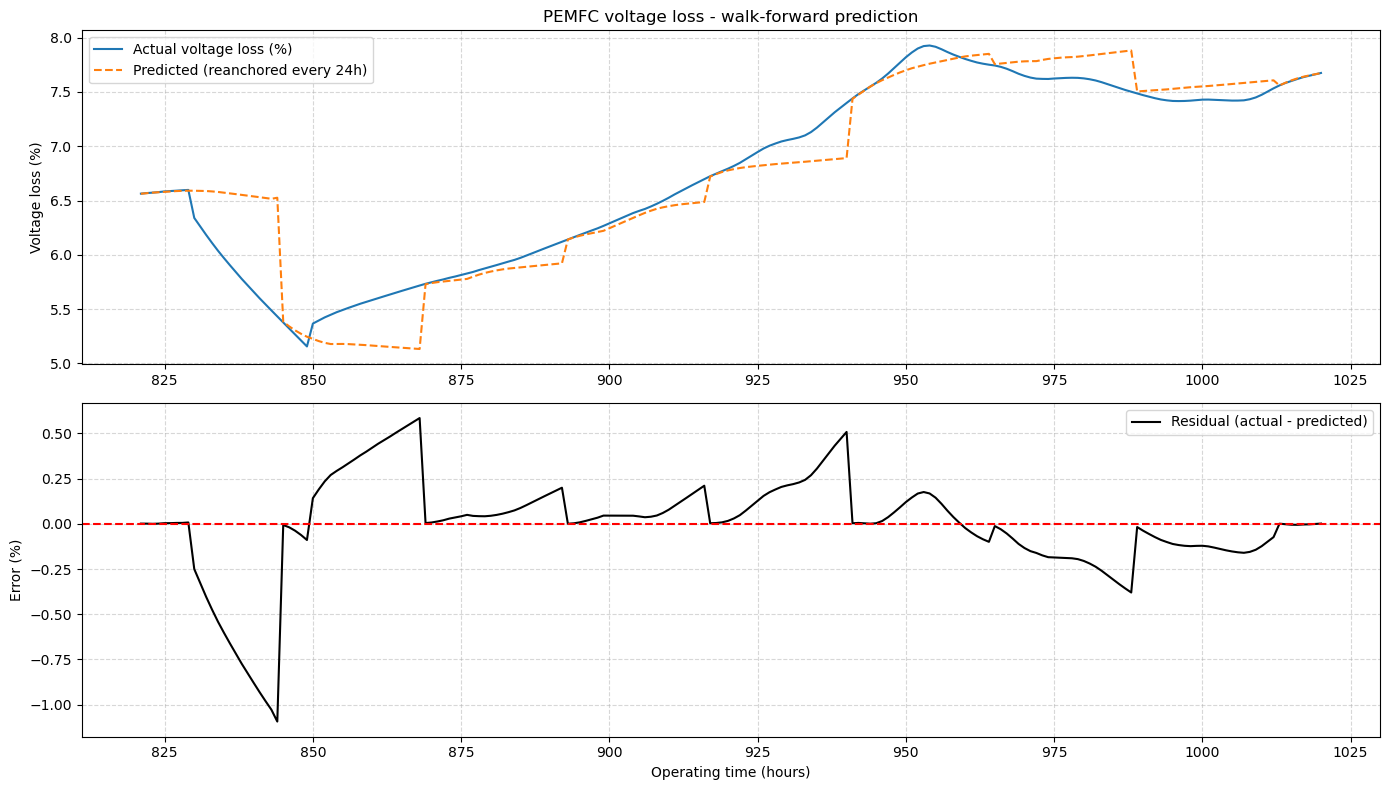

In [8]:
# Plotting the results

print("MAE: ", mean_absolute_error(actual, reconstructed))
print("RMSE:", np.sqrt(mean_squared_error(actual, reconstructed)))
print("R2:  ", r2_score(actual, reconstructed))

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop feature importances:")
print(importances.head(10))

test_hours = data["hours_elapsed"].values[split_idx:]
residuals = actual - reconstructed

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(test_hours, actual, label="Actual voltage loss (%)")
plt.plot(test_hours, reconstructed, label="Predicted (reanchored every 24h)", linestyle="--")
plt.title("PEMFC voltage loss - walk-forward prediction")
plt.ylabel("Voltage loss (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(2, 1, 2)
plt.plot(test_hours, residuals, color="black", label="Residual (actual - predicted)")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Operating time (hours)")
plt.ylabel("Error (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
data.columns

Index(['hours_elapsed', 'I (A)', 'TinWAT (ｰC)', 'ToutH2 (ｰC)', 'ToutAIR (ｰC)',
       'target', 'I (A)_lag1', 'I (A)_lag6', 'I (A)_lag24', 'I (A)_rollmean6',
       'I (A)_rollmean24', 'TinWAT (ｰC)_lag1', 'TinWAT (ｰC)_lag6',
       'TinWAT (ｰC)_lag24', 'TinWAT (ｰC)_rollmean6', 'TinWAT (ｰC)_rollmean24',
       'ToutH2 (ｰC)_lag1', 'ToutH2 (ｰC)_lag6', 'ToutH2 (ｰC)_lag24',
       'ToutH2 (ｰC)_rollmean6', 'ToutH2 (ｰC)_rollmean24', 'ToutAIR (ｰC)_lag1',
       'ToutAIR (ｰC)_lag6', 'ToutAIR (ｰC)_lag24', 'ToutAIR (ｰC)_rollmean6',
       'ToutAIR (ｰC)_rollmean24', 'target_diff', 'target_diff_lag1',
       'target_diff_lag6', 'target_diff_lag24'],
      dtype='object')